# Exploring General Domain Negative Samples (O class)

This notebook explores the generation and purpose of general domain negative samples. These sentences contain no entities (all labels are **O**), which teaches the NER model not to predict labels on non-nutritional/non-medical conversational words. We will plot the sentence length distribution of these negative samples.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Subjects representing common generic questions/concepts (non-food, non-medical)
subjects = [
    "the capital of France", "the speed of light", "the height of Mount Everest", "the population of Tokyo",
    "the author of Hamlet", "the president of America", "the CEO of Microsoft", "the size of the solar system",
    "the rules of soccer", "the definition of inflation", "the behavior of black holes", "the concept of quantum physics",
    "the development of the internet", "the architecture of the Eiffel Tower", "the structure of the bridge",
    "the meaning of life", "the history of music", "the play Romeo and Juliet", "the painting Mona Lisa",
    "the discovery of America", "the launch of the rocket", "the software development lifecycle",
    "the database schema design", "the git commit message format", "the web browser search history",
    "the weather forecast for tomorrow", "the flight schedule to London", "the train ticket booking system",
    "the currency exchange rate", "the stock market index value", "the rules of chess", "the capital of Japan",
    "the history of the Roman Empire", "the distance to Mars", "the length of the Amazon river",
    "the author of Harry Potter", "the inventor of the light bulb", "the prime minister of Canada",
    "the founder of Apple", "the design of the smartphone", "the features of the new car",
    "the schedule of the conference", "the results of the match", "the location of the museum",
    "the price of the gold", "the oil production rate", "the interest rate of the bank",
    "the details of the project", "the architecture of the building", "the layout of the keyboard",
    "the language of Brazil", "the flag of Germany", "the population of India", "the history of the movie",
    "the song of the artist", "the performance of the computer", "the speed of the network",
    "the configuration of the server", "the documentation of the API", "the source code of the app"
]

# 2. Common template questions
templates = [
    "What is {subject}?",
    "How do you explain {subject}?",
    "Who is responsible for {subject}?",
    "Can you explain {subject}?",
    "Show me {subject}.",
    "Tell me about {subject}.",
    "What do you know about {subject}?",
    "Why is {subject} important?",
    "Where can I find {subject}?",
    "Is {subject} available online?",
    "Please describe {subject}.",
    "Who discovered {subject}?",
    "What is the history of {subject}?",
    "How does {subject} work?",
    "Can we look at {subject}?"
]

In [2]:
# 3. Generate negative samples
negative_samples = []
for sub in subjects:
    for temp in templates:
        text = temp.format(subject=sub)
        tokens = text.strip().split()
        if len(tokens) >= 3:
            negative_samples.append({
                "tokens": tokens,
                "labels": ["O"] * len(tokens)
            })

print(f"Total generated negative samples: {len(negative_samples)}")

Total generated negative samples: 900


## 4. Visualizations

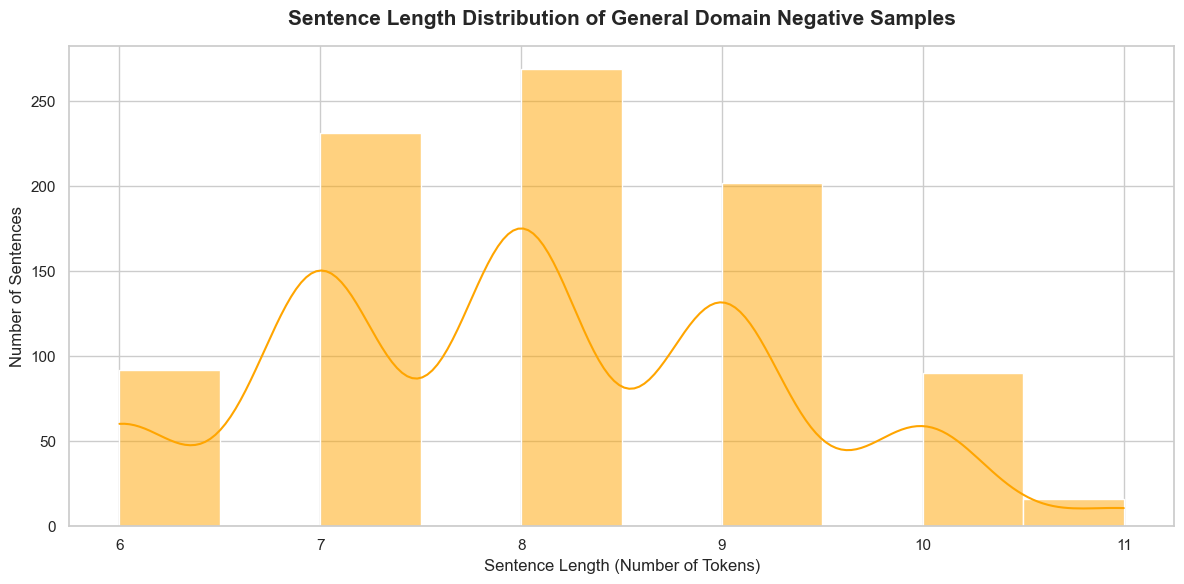

In [3]:
sns.set_theme(style="whitegrid")

# Plot sentence length distribution
sent_lengths = [len(s['tokens']) for s in negative_samples]

plt.figure(figsize=(12, 6))
sns.histplot(sent_lengths, bins=10, kde=True, color="orange")
plt.title("Sentence Length Distribution of General Domain Negative Samples", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Sentence Length (Number of Tokens)", fontsize=12)
plt.ylabel("Number of Sentences", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
print("Sample generated sentences (All tokens labeled as 'O'):")
for idx, sample in enumerate(negative_samples[:10]):
    sentence = " ".join(sample['tokens'])
    print(f"  {idx+1:02d}. {sentence}")

Sample generated sentences (All tokens labeled as 'O'):
  01. What is the capital of France?
  02. How do you explain the capital of France?
  03. Who is responsible for the capital of France?
  04. Can you explain the capital of France?
  05. Show me the capital of France.
  06. Tell me about the capital of France.
  07. What do you know about the capital of France?
  08. Why is the capital of France important?
  09. Where can I find the capital of France?
  10. Is the capital of France available online?


## 5. Why are these negative samples important?
In clinical/biomedical datasets like BC5CDR, there are no "general" conversation lines. If we only train our BioBERT model on BC5CDR and FoodBase, the model might learn that **every sentence must contain some entity**. 

As a result, when a user asks a general question like "*What is the population of Tokyo?*", the model might hallucinate and classify "*Tokyo*" as `FOOD` or `DISEASE` because it has never seen sentences with only **O** labels during training.

Adding these **900 negative samples** teaches the model to assign the **O** label when no medical/nutritional concepts are present.